# LKIPA Time Series Data Collection

In this notebook we analyse the noise power of the LKIPA from its power spectrum density. 

----

In [17]:
# IMPORTS
# =======
import os
import sys

import matplotlib.pyplot as plt
%matplotlib widget
import numpy as np
from tqdm import tqdm

from presto import test
from presto import lockin, utils
from presto.hardware import AdcMode, DacMode, AdcFSample, DacFSample
import importlib
import presto_config as pc
importlib.reload(pc)


<module 'presto_config' from '/home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/LKIPA Measurements/presto_config.py'>

# 1. Get PSD from time series pixels

In [18]:
# DATA ACQUISITION
data_all, dt, fs, n_samples = pc.data_acquisition(
            address=pc.ADDRESS,
            port=pc.PORT,
            converter_configuration=pc.CONVERTER_CONFIGURATION,
            input_port=pc.INPUT_PORT,
            adc_att=pc.ADC_ATT,
            input_nco=pc.INPUT_NCO,
            output_port=pc.FLUX_PORT,
            dac_curr=pc.DAC_CURR,
            amp=pc.PUMP_AMP,
            freq=pc.PUMP_FREQ,
            phasei=pc.PHASEI,
            phaseq=pc.PHASEQ,
            output_nco=pc.PUMP_NCO,
            df=pc.DF,
            dcb_port=pc.DC_PORT,
            dcb_amp=pc.DC_BIAS,
            n_pix=pc.N_PIX
        )

# REMOVE DC COMPONENT AND UNTWIST I\Q quadratures
I_all = pc.remove_DC(data_all=data_all)


Hardware configuration successful, initiating data acquisition ...


100%|███████████████████████████████████████| 5000/5000 [03:22<00:00, 24.71it/s]


Data Acquisition Complete.
MEASUREMENT PARAMETERS:
Mode: AdcMode.Mixed
Number of pixels: 5000
Pixel time resolution (dt): 1.00 ns
Sampling frequency (fs): 1.00 GHz
Total measurement time: 100.0 µs
Frequency resolution (DF): 10.0 kHz
Data points captured per pixel: 200000
Number of samples per pixel: 100000
Data format: Mixed mode (I and Q interleaved)
Shape of I data: (5000, 100000)


FITTING PARAMETERS:
A_background =  1.14
B_background =  -0.33
A_peak =  0.16
f0 =  4.42972 GHz
gamma =  0.539 MHz


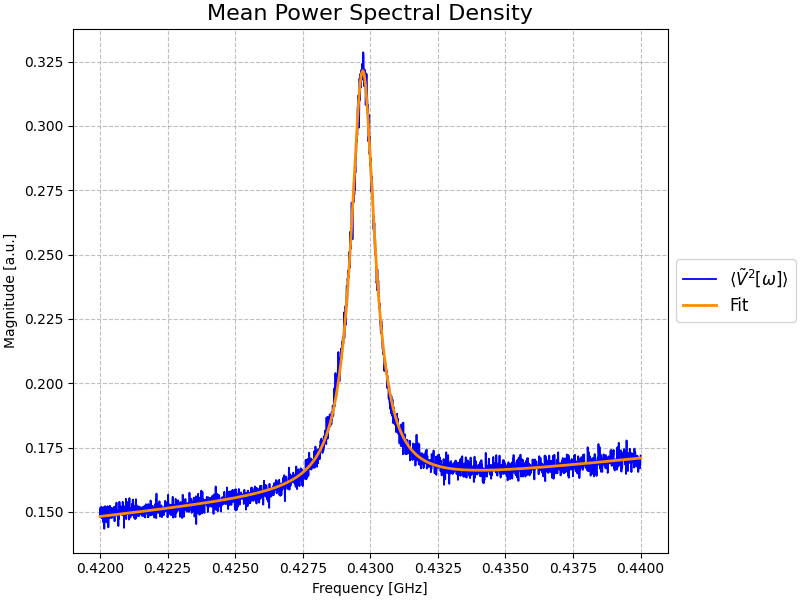

In [22]:
# GET POWER SPECTRAL DENSITY
PSD_avg, f_arr, t_arr = pc.get_PSD_avg(
    I_all=I_all,
    n_samples=n_samples,
    dt=dt
)

# SELECT BANDWIDTH
PSD_bw, f_bw = pc.get_PSD_bw(
    PSD_avg=PSD_avg,
    f_arr=f_arr,
    f_L=0.42,
    f_R=0.44
)

# PLOT PSD
pc.plot_PSD_bw(
    PSD_bandwidth=PSD_bw,
    f_arr_bandwidth=f_bw
)